<a href="https://colab.research.google.com/github/NawfelStudent/PFE-Netclassifier-Projet/blob/main/02-app-classification/02b-comparative-modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning for Traffic Classification

With our high-quality, purpose-built datasets now prepared, we enter the modeling phase. This chapter will walk through a systematic, comparative process of building, evaluating, and understanding several representative machine learning algorithms for the task of network traffic classification.

Our approach will follow the **"Three-Act" modeling strategy** we defined at the end of the previous chapter:

1.  **Act 1: The Foundational Bake-Off.** We will begin with a controlled **10-class problem** using **statistical features** to systematically compare classic ML algorithms and their evaluation.
2.  **Act 2: The Advanced SPLT Experiment.** We will then use the same 10-class subset to evaluate the predictive power of **raw sequence features** alone.
3.  **Act 3: The "Real-World" Challenge.** Finally, we will tackle the full **63-class problem**, focusing on the specific challenges of many-class classification.

---

## Setup and Reproducibility

### Project Repository Setup

Before we can begin modeling, we need to ensure that all the required files are downloaded. We clone only the required parts of the `ml-flow-class-tutorial` repository using a sparse checkout. We intentionally avoid downloading the full repo to keep the directory clean.



In [1]:
# Clone the project repository (without downloading all blobs)
!git clone --filter=blob:none --sparse -n https://github.com/FlowFrontiers/ml-flow-class-tutorial.git 2> >(grep -v '^remote:')

# Navigate into the repo and select only the data files we need
!cd ml-flow-class-tutorial && git sparse-checkout set 02-app-classification/requirements-ml.txt 02-app-classification/data/final_dataset_10_classes_statistical.parquet 02-app-classification/data/final_dataset_10_classes_splt.parquet 02-app-classification/data/final_dataset_63_classes_statistical.parquet
!cd ml-flow-class-tutorial && git checkout 2> >(grep -v '^remote:')

# Navigate to the working directory
import os
os.chdir('ml-flow-class-tutorial/02-app-classification')


Cloning into 'ml-flow-class-tutorial'...
Your branch is up to date with 'origin/main'.


After this step, we have:
- the `data/` directory with the three Parquet files developed in the first part of this tutorial
- the `requirements-ml.txt` script

Next, we install the required Python packages.

In [2]:
# Install the required packages
!pip install -r requirements-ml.txt 2>&1 | grep -E "(Instal|Update|Setup|ERROR|FAILED)"

### A Note on Our Environment

The setup you just ran creates a consistent, stable environment. Here is what you need to know about it.

**1. A Locked, Stable Environment**
The `pip install -r requirements-ml.txt` command you just ran is a standard practice that installs the *exact* versions of the software libraries (`scikit-learn`, `pandas`, `numpy`, etc.) that were used to generate the final results in this notebook. To make the setup as smooth as possible, the versions in our file have been set to match the default packages in the Google Colab environment as of November 2025.

**2. A Note on Installation Messages**
Because we are matching Colab's current environment, the installation should complete quickly and without any red error messages. However, Google updates its environment periodically. If you are running this notebook several months or years in the future, you **might** see red text mentioning **"dependency conflicts."** This is normal and happens when our locked versions conflict with newer packages pre-installed by Colab. **If you see these messages, they can be safely ignored.**

**3. Expect Minor Numerical Variations**
The world of data science involves complex interactions between code, software packages, and hardware.
Even with identical software, you might see minuscule differences in the final decimal places of some results (e.g., an F1-score of `0.841` here might be `0.840` on your machine). This is also normal and can be caused by:
*   **Different Hardware:** This tutorial was generated on a Google Colab instance with an Intel (x86-64) CPU.  If you run it on a different machine, like a MacBook with an Apple (ARM) processor, the low-level libraries that perform the mathematical calculations are different.
*   **Different Python Versions:** The results were standardized on Python 3.12.12 (main, Oct 10 2025, 08:52:57). Minor differences can occur on other versions as different Python interpreters can have subtle differences in how they handle underlying operations.

**The Bottom Line:** The dependency warnings (if they appear) are harmless, and any tiny numerical differences are normal. They **do not change the overall conclusions of the tutorial.** A model that is better will still be better, and the patterns you see will be the same.

### Verifying Our Environment
Let's quickly print the versions of our key libraries to confirm the setup.

In [3]:
import sys
from importlib import metadata

# Print Python version
print(f"Python Version: {sys.version}\n")

packages = [
    'scikit-learn', 'pandas', 'numpy', 'lightgbm',
    'imbalanced-learn', 'matplotlib', 'seaborn'
]

print("--- Key Package Versions ---")
for pkg in packages:
    try:
        version = metadata.version(pkg)
        print(f"{pkg}=={version}")
    except metadata.PackageNotFoundError:
        print(f"{pkg} is not installed.")

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

--- Key Package Versions ---
scikit-learn==1.6.1
pandas==2.2.2
numpy==2.0.2
lightgbm==4.6.0
imbalanced-learn==0.14.0
matplotlib==3.10.0
seaborn==0.13.2


---

## 1. Act 1: Modeling with Statistical Features

With our environment ready, let's begin. Our first goal is to compare the performance of several representative Machine Learning Algorithms (MLAs). We will evaluate:

1.  **Logistic Regression:** A fast, interpretable linear model that serves as a strong baseline.
2.  **LightGBM:** A state-of-the-art gradient boosting framework.
3.  **Random Forest:** A powerful ensemble of decision trees, known for high accuracy.
4.  **Multi-Layer Perceptron (MLP):** A foundational neural network model.

For this initial bake-off, we will focus on the **coarse-grained classification problem**, where our goal is to predict the general `application_category_name`.

---

### 1.1. Data Preparation

Our first task is to compare four classic machine learning models. To do this in a clear and interpretable way, we will use our curated 10-class dataset.

The first step is to load the data and prepare our feature matrix (`X`) and target vector (`y`).

In [4]:
import pandas as pd
import numpy as np

# --- 1. Load the Dataset for Act 1 ---
# This is our curated 10-class dataset containing only statistical features.
DATA_PATH = 'data/final_dataset_10_classes_statistical.parquet'
df_act1 = pd.read_parquet(DATA_PATH)

print(f"Loaded dataset for Act 1 with shape: {df_act1.shape}")

# --- 2. Prepare the Feature Matrix (X) and Target Vector (y_coarse) ---
# Define our target for this coarse-grained classification task
TARGET_COLUMN_COARSE = 'application_category_name'
# TARGET_COLUMN_FINE = 'application_name'

# The feature matrix 'X' contains all columns EXCEPT the two potential labels
X = df_act1.drop(columns=['application_name', 'application_category_name'])

# The target vector 'y_coarse' contains only our chosen label
y_coarse = df_act1[TARGET_COLUMN_COARSE]
# y_fine = df_act1[TARGET_COLUMN_FINE]

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y_coarse.shape}")
print("\n--- Target Variable Distribution (y) ---")
print(y_coarse.value_counts(normalize=True).apply("{:.2%}".format))

Loaded dataset for Act 1 with shape: (106528, 57)
Feature matrix X shape: (106528, 55)
Target vector y shape: (106528,)

--- Target Variable Distribution (y) ---
application_category_name
Web              24.39%
Collaborative    21.69%
SocialNetwork    19.81%
Media            11.55%
Game              6.43%
Advertisement     5.92%
Music             5.64%
Download          4.34%
Cloud             0.23%
Name: proportion, dtype: object


With our data loaded and variables prepared, we are ready to begin the comparative analysis.

----

### 1.2. Model 1: Logistic Regression (The Baseline)

We start with Logistic Regression. Before training any model, we must split our data into a training set (for the model to learn from) and a testing set (to evaluate its performance on unseen data). We will use a standard 80/20 split. Crucially, we use `stratify=y_coarse` to ensure that the class distribution in both the training and testing sets is the same as in the original dataset. This is vital given the class imbalance we observed.

Furthermore, linear models like Logistic Regression are sensitive to the scale of features. We will use `StandardScaler` to standardize our features by removing the mean and scaling to unit variance. **To establish a true baseline, we will first train the model without any explicit class weighting to see how a standard algorithm performs on our imbalanced data.**

Training Logistic Regression model...
Making predictions...

--- Classification Report for Logistic Regression ---
               precision    recall  f1-score   support

Advertisement       0.29      0.00      0.00      1262
        Cloud       0.33      0.02      0.04        50
Collaborative       0.88      0.90      0.89      4622
     Download       0.94      0.90      0.92       924
         Game       0.76      0.69      0.72      1369
        Media       0.72      0.38      0.49      2460
        Music       0.33      0.04      0.07      1201
SocialNetwork       0.91      0.91      0.91      4221
          Web       0.56      0.94      0.70      5197

     accuracy                           0.73     21306
    macro avg       0.63      0.53      0.53     21306
 weighted avg       0.72      0.73      0.69     21306


--- Confusion Matrix ---


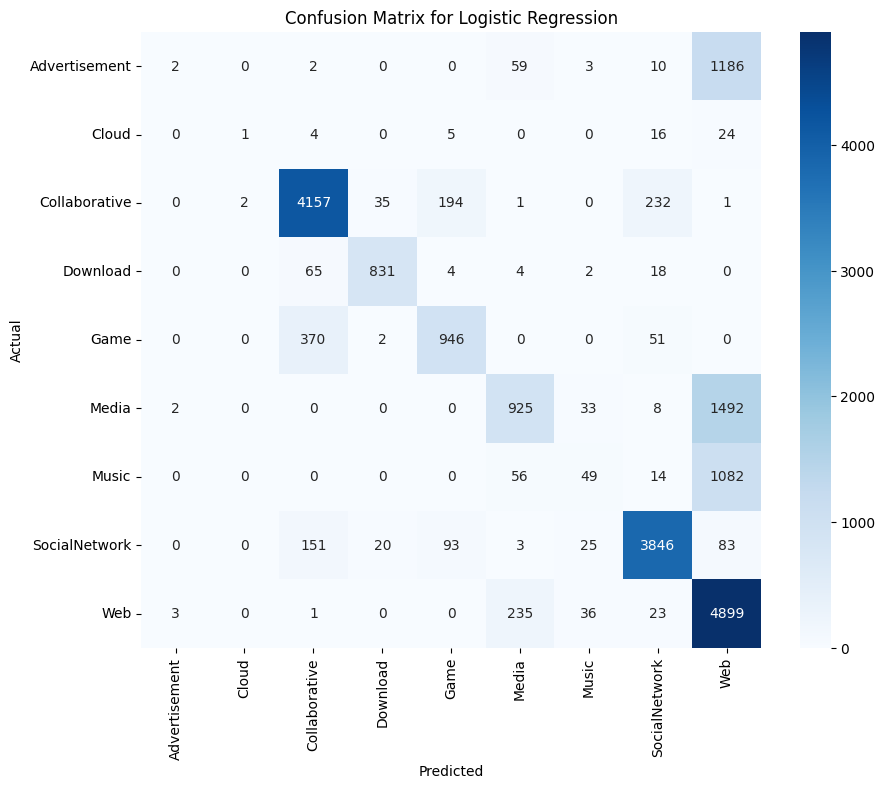

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split the data into training and testing sets (80/20)
# We use stratify to maintain the same class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_coarse, test_size=0.2, random_state=42, stratify=y_coarse)

# Apply standard scaling to the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Logistic Regression model
# We use n_jobs=-1 to use all available CPU cores
lr_clf = LogisticRegression(random_state=42, n_jobs=-1, max_iter=1000) # Increased max_iter for convergence
print("Training Logistic Regression model...")
lr_clf.fit(X_train_scaled, y_train)

# Make predictions on the test set
print("Making predictions...")
y_pred_lr = lr_clf.predict(X_test_scaled)

# Evaluate the model
print("\n--- Classification Report for Logistic Regression ---")
print(classification_report(y_test, y_pred_lr))

# Visualize the confusion matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lr_clf.classes_, yticklabels=lr_clf.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Analysis of Logistic Regression Results:**

The results from our baseline Logistic Regression model immediately highlight the profound challenge posed by class imbalance in our dataset.

*   **Overall Accuracy:** The model achieves an overall accuracy of **73%**. While not terrible, this number is misleading because it is heavily skewed by the model's performance on the more frequent classes like `Web`, `SocialNetwork`, and `Collaborative`.

*   **Precision and Recall - The True Story:** The per-class metrics reveal the model's true, and highly uneven, performance:
    *   **Majority Classes:** For well-represented classes like `Collaborative` and `SocialNetwork`, the model performs reasonably well, with F1-scores of 0.89 and 0.91 respectively. For the most frequent class, `Web`, it achieves a very high recall (0.94), meaning it's good at finding `Web` traffic.
    *   **Minority Class Collapse:** Performance completely collapses for the rare classes. `Advertisement` has a recall of **0.00**—it fails to identify a single advertisement flow. `Cloud` and `Music` are similarly ignored, with recall scores of just 0.02 (2%) and 0.04 (4%) respectively. The model has learned that it can achieve a high overall score by focusing on the big classes and effectively ignoring the small ones.

*   **Macro Avg vs. Weighted Avg:** This performance gap is perfectly summarized by the F1-scores.
    *   The **weighted avg (0.69)** is propped up by the large classes.
    *   The **macro avg (0.53)**, which treats all classes equally, is significantly lower. This large gap between the two averages is a classic statistical signature of a model that has failed to learn the minority classes. It provides a much more honest assessment of the model's limited overall utility.

*   **Confusion Matrix:** The heatmap provides a stark visual confirmation of the problem.
    *   The diagonal is brightly colored for the largest classes, with massive numbers like **4899** for `Web`, **3846** for `SocialNetwork`, and **4157** for `Collaborative`, indicating many correct predictions.
    *   In contrast, the minority classes demonstrate the model's failure. Looking at the `Advertisement` row (Actual), we see a tiny **2** on the diagonal. The model correctly identifies only two instances, while misclassifying the vast majority, primarily as **`Web` (1186 instances)**.
    *   Similarly, for the rarest class, `Cloud`, only **1** flow is correctly identified. The rest are scattered and misclassified, again with `Web` being the most common incorrect prediction (24 instances).
    *   The pattern is clear: the model has learned a simplistic rule to deal with uncertainty: "if unsure, predict `Web`."

**Baseline Verdict:** As a baseline, Logistic Regression has perfectly established the nature of our problem. It is a linear model that struggles to find the complex, non-linear boundaries needed to separate minority classes from the majority. It performs adequately on the most common traffic types but is practically useless for identifying rare but potentially important categories like `Cloud` or `Advertisement`. This result powerfully underscores the need for more complex, non-linear models that can learn the intricate patterns required to solve our imbalanced classification task.

---

### 1.3. Model 2: LightGBM

LightGBM is a high-performance gradient boosting framework that is often a top contender for tabular data problems. Unlike Random Forest, which builds independent trees, gradient boosting builds trees sequentially, where each new tree attempts to correct the errors of the previous ones. This can lead to very high accuracy but also makes the model more sensitive to its parameters and training data characteristics.

LightGBM is a tree-based model and is not inherently sensitive to feature scaling. For the sake of a consistent experimental setup, we will continue to use the same scaled data.

**A Note on Verbosity:** When running LightGBM, the library often produces detailed `[Info]` and `[Warning]` messages.
*   The `[Info]` messages describe the internal setup (e.g., threading, data binning, initial scores).
*   The `[Warning] No further splits with positive gain...` message is common and simply means that during the construction of a tree, the algorithm reached a point where it could not find a beneficial split to improve the model, so it stopped growing that particular branch.

While useful for deep debugging, this verbosity can clutter our output. We will suppress it by setting the `verbosity=-1` parameter.

You may also see a `UserWarning` related to missing feature names. This occurs because our `StandardScaler` converts the pandas DataFrame (which has column names) into a NumPy array (which does not).
<!-- Since our pipeline guarantees the feature order is identical for both training and testing, this warning is informational and can be safely ignored.  -->
By explicitly recreating the DataFrame after scaling, we provide the model with the feature names during both `fit` and `predict`, which satisfies the library's internal validation checks and suppresses the warning. This approach is more robust and considered a better practice for building complex pipelines.

Training LightGBM model...
Making predictions...

--- Classification Report for LightGBM ---
               precision    recall  f1-score   support

Advertisement       0.81      0.59      0.68      1262
        Cloud       0.47      0.52      0.50        50
Collaborative       0.99      0.99      0.99      4622
     Download       1.00      0.99      1.00       924
         Game       0.97      0.98      0.97      1369
        Media       0.87      0.79      0.83      2460
        Music       0.95      0.93      0.94      1201
SocialNetwork       0.99      0.99      0.99      4221
          Web       0.83      0.93      0.88      5197

     accuracy                           0.92     21306
    macro avg       0.88      0.86      0.86     21306
 weighted avg       0.92      0.92      0.92     21306


--- Confusion Matrix ---


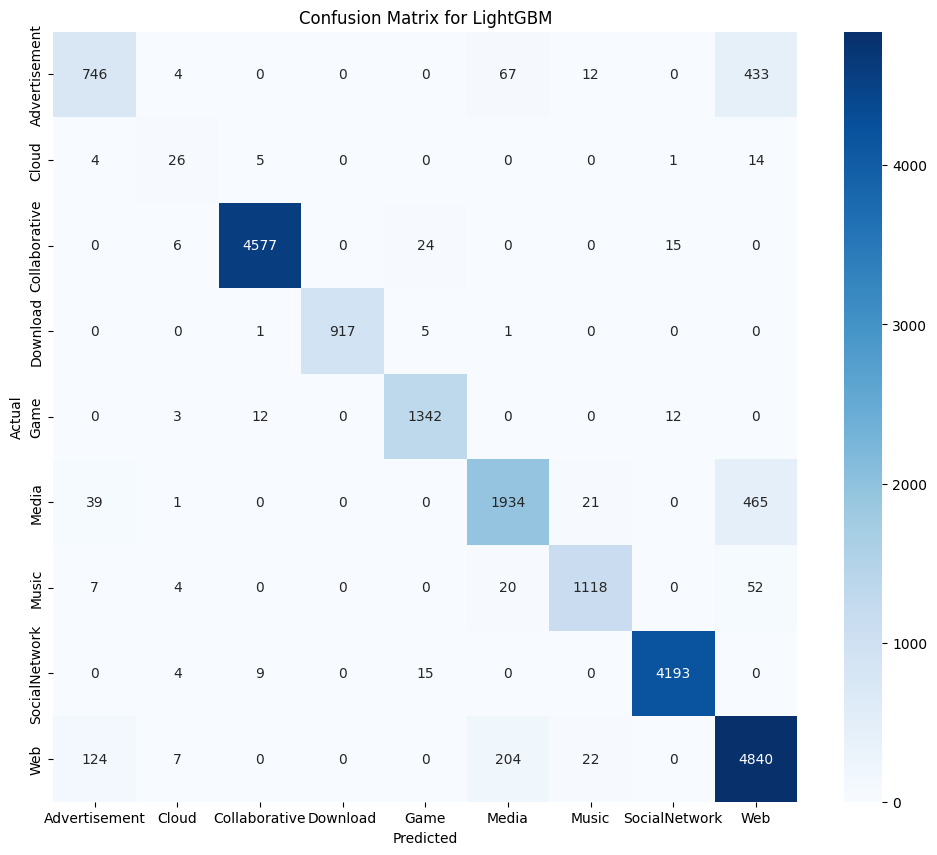

In [6]:
import lightgbm as lgb

# Apply standard scaling. NOTE: scaler.transform returns a NumPy array.
# We will convert it back to a DataFrame to preserve feature names,
# which is a best practice that prevents potential warnings or errors.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# NOTE: Tree-based models like LightGBM do not require feature scaling.
# However, to maintain a consistent experimental pipeline across all models,
# we will use the same scaled data that we prepared for Logistic Regression.
# This ensures a fair and direct comparison.

# Initialize and train the LightGBM model
# We set verbosity=-1 to suppress noisy info/warning messages
lgbm_clf = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbosity=-1)
print("Training LightGBM model...")
lgbm_clf.fit(X_train_scaled, y_train)

# Make predictions on the test set
print("Making predictions...")
y_pred_lgbm = lgbm_clf.predict(X_test_scaled)

# Evaluate the model
print("\n--- Classification Report for LightGBM ---")
print(classification_report(y_test, y_pred_lgbm, digits=2))

# Visualize the confusion matrix
print("\n--- Confusion Matrix ---")
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', xticklabels=lgbm_clf.classes_, yticklabels=lgbm_clf.classes_)
plt.title('Confusion Matrix for LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Analysis of LightGBM Results:**

The switch from a linear model to a powerful, tree-based ensemble like LightGBM yields a **dramatic and impressive improvement** across nearly all metrics.

*   **Overall Accuracy:** The accuracy has jumped from 73% to **92%**, a massive leap that indicates the model is capturing the underlying patterns far more effectively.

*   **Minority Class Recall:** This is the most significant result. The recall for the minority classes, which was the primary failure of Logistic Regression, has skyrocketed.
    *   **`Advertisement`:** Recall soared from near-zero to **0.59 (59%)**.
    *   **`Cloud`:** Recall jumped from a dismal 2% to a very respectable **0.52 (52%)**.
    *   **`Music`:** Recall increased from 4% to an excellent **0.93 (93%)**.
    This demonstrates the model's ability to learn the distinct, non-linear patterns of even the rarest classes.

*   **Macro Avg vs. Weighted Avg:** The gap between these two metrics has significantly narrowed. The **macro avg F1-score is now 0.86**, much closer to the **weighted avg of 0.92**. This is strong statistical proof that the model is performing well across *all* classes, not just the dominant ones. The gap hasn't vanished entirely, indicating some remaining difficulty with the smallest classes, but the improvement is substantial.

*   **Confusion Matrix:** The heatmap tells a story of huge success compared to the baseline.
    *   The diagonal is now intensely colored for **almost all classes**, including the minorities, indicating a strong predictive performance across the board.
    *   For `Advertisement`, we now see a robust **746** correct predictions on the diagonal, a stark contrast to the baseline's complete failure. While a significant number of `Advertisement` flows are still misclassified as `Web` (433), the model has clearly learned to distinguish the majority of them.
    *   For the rarest class, `Cloud`, the model correctly identifies **26** flows. While this number is small, it represents a recall of 52% (26 out of 50), which is a massive improvement and demonstrates the model's ability to learn the patterns of even the most underrepresented classes.

**Verdict for LightGBM:** The LightGBM model is a resounding success compared to the linear baseline. Its ability to create complex, non-linear decision boundaries allows it to effectively isolate and identify even small minority classes. By building trees sequentially to correct errors, it has learned the intricate "shapes" of each traffic class in the high-dimensional feature space. This result powerfully demonstrates the importance of moving beyond linear baselines for complex classification problems. The bar has now been set very high for our subsequent models.

----

### 1.4. Model 3: Random Forest

Next, we evaluate a Random Forest classifier. This is an ensemble learning method that builds a multitude of decision trees and combines their predictions. As a powerful, non-linear model, it can learn much more complex patterns than Logistic Regression.

A key difference from linear models is that tree-based ensembles like Random Forest are not sensitive to feature scaling. While we use the same scaled data for consistency, it is not a requirement for this model type.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# NOTE: Random Forest is a tree-based model that does not require feature scaling.
# We use the scaled data here purely for consistency with our experimental pipeline.

# Initialize and train the Random Forest model
# n_estimators=100 means we will build 100 trees
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("Training Random Forest model...")
rf_clf.fit(X_train_scaled, y_train)

# Make predictions on the test set
print("Making predictions...")
y_pred_rf = rf_clf.predict(X_test_scaled)

# Evaluate the model
print("\n--- Classification Report for Random Forest ---")
print(classification_report(y_test, y_pred_rf))

# Visualize the confusion matrix
print("\n--- Confusion Matrix ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=rf_clf.classes_, yticklabels=rf_clf.classes_)
plt.title('Confusion Matrix for Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Training Random Forest model...


**Analysis of Random Forest Results:**

The Random Forest classifier continues the trend of strong performance from tree-based ensembles, delivering results that are, in several key areas, even slightly better than those from LightGBM.

*   **Overall Accuracy:** The model achieves an excellent overall accuracy of **93%**, marginally improving upon the previous model and demonstrating a very high degree of correctness.

*   **Minority Class Performance:** Random Forest shows a slightly better ability to handle the most challenging minority classes.
    *   **`Advertisement`:** Recall has improved to **0.63 (63%)**, the best result so far for this difficult class.
    *   **`Cloud`:** Recall has also seen a slight improvement, rising to **0.54 (54%)**.
    This indicates that the model's approach of using an ensemble of deep, independent trees is very effective at carving out the decision boundaries for these rare categories.

*   **Macro Avg vs. Weighted Avg:** The gap between the two F1-score averages has narrowed even further. The **macro avg (0.89)** is now very close to the **weighted avg (0.93)**. This is a strong sign of a well-balanced model that performs robustly across all classes, both large and small.

*   **Confusion Matrix:** The heatmap confirms the model's strong, balanced performance.
    *   The diagonal is intensely populated, showing high numbers of correct predictions across the board (e.g., **4882** for `Web`, **4571** for `Collaborative`).
    *   For the `Advertisement` class, the model correctly identifies **795** flows—the best performance yet. While significant confusion with the `Web` class (**390** instances) persists, this is a clear improvement.
    *   For the `Cloud` class, the model correctly classifies **27** of the 50 instances, again showing a slight edge over the previous model.

**Verdict for Random Forest:** The Random Forest model is another resounding success and currently stands as our **top-performing classifier**. It builds on the strengths of tree-based ensembles and delivers a slightly more balanced performance, with superior recall on the most underrepresented classes. By combining the predictions of hundreds of independent decision trees, it has learned the data's complex patterns with very high fidelity.

---

### 1.5. Model 4: Multi-Layer Perceptron (MLP)

Finally, we explore a foundational neural network model: the Multi-Layer Perceptron (MLP). MLPs can learn highly complex, non-linear relationships and are the basis for deep learning. They consist of an input layer, one or more hidden layers, and an output layer.

We will use `sklearn.neural_network.MLPClassifier` with a simple architecture. Neural networks are critically sensitive to feature scaling, making our standardized dataset essential for good performance.

**A Note on Training and Convergence:** A crucial aspect of training iterative models like MLPs is ensuring they reach **convergence**—the point where the model's performance on the validation data no longer improves. The `max_iter` parameter, which sets the maximum number of training epochs, is key to this process.

A common pitfall is setting `max_iter` too low. This can halt training prematurely, leading to an undertrained model and a `ConvergenceWarning`. Best practice is to set a generous `max_iter` to allow the model sufficient time to converge. The solver will stop automatically if the validation score stops improving, so a high value does not necessarily mean longer training times if convergence is reached early.

However, for the purposes of this tutorial, we will set a low value of `max_iter=15` to ensure that the cell executes quickly. Be aware that this is **not a recommended practice for a real-world application**, as the model will likely not converge fully. For instance, with a more appropriate value like `max_iter=500`, the model would be far more likely to converge, but the training process, depending on the system/instance resources used, could take over 10 minutes to complete.

In [ ]:
from sklearn.neural_network import MLPClassifier

# Initialize and train the MLP model
# hidden_layer_sizes: A tuple representing the number of neurons in each hidden layer.
# max_iter: Maximum number of iterations for the solver to converge.
# alpha: L2 penalty (regularization term) parameter.
# solver: The solver for weight optimization. 'adam' works well for large datasets.
mlp_clf = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=15, alpha=0.0001, solver='adam', random_state=42, verbose=True)
print("Training MLP model...")
mlp_clf.fit(X_train_scaled, y_train)

# Make predictions on the test set
print("Making predictions...")
y_pred_mlp = mlp_clf.predict(X_test_scaled)

# Evaluate the model
print("\n--- Classification Report for MLP ---")
print(classification_report(y_test, y_pred_mlp))

# Visualize the confusion matrix
print("\n--- Confusion Matrix ---")
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=mlp_clf.classes_, yticklabels=mlp_clf.classes_)
plt.title('Confusion Matrix for MLP')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Analysis of MLP Results:**

The Multi-Layer Perceptron (MLP), our first neural network model, delivers a solid performance but does not reach the top-tier results of the tree-based ensembles. This provides an interesting contrast and a lesson in model selection.

*   **Overall Accuracy:** The model achieves a good overall accuracy of **84%**. While this is a massive improvement over the linear baseline, it is a noticeable step down from the 92-93% accuracy of the LightGBM and Random Forest models.

*   **Minority Class Recall:** This is where the MLP struggles the most compared to the tree-based models.
    *   **`Advertisement`:** Recall is only **0.19 (19%)**.
    *   **`Cloud`:** Recall is **0.22 (22%)**.
    While this is far better than the baseline, it is significantly weaker than the ~50-60% recall achieved by the ensembles for these same classes. The MLP appears to be more sensitive to the severe class imbalance.

*   **Macro Avg vs. Weighted Avg:** The performance gap between the averages has widened again. The **macro avg F1-score of 0.74** is noticeably lower than the **weighted avg of 0.83**. This statistically confirms that the MLP's performance is less balanced across classes than the tree-based models.

*   **Confusion Matrix:** The heatmap visually confirms these findings.
    *   For the `Advertisement` class, only **243** flows are correctly identified, while a large number are misclassified as `Web` (825) or `Media` (132).
    *   For the `Cloud` class, only **11** flows are correctly identified out of 50.
    *   While the model performs very well on the large, well-defined classes like `Collaborative` and `SocialNetwork`, and `Web`, it clearly struggles to define the decision boundaries for the smaller minority classes.

**Verdict for MLP:** In this comparative analysis, the simple MLP architecture proves to be a good, but not great, performer. It soundly beats the linear baseline but is outperformed by the tree-based ensembles, particularly in its ability to handle the most underrepresented classes. This is a crucial lesson: while neural networks are incredibly powerful, a simple, out-of-the-box MLP is not a guaranteed "silver bullet" and may require more careful tuning, architectural changes, or specific imbalance-handling techniques (like SMOTE) to compete with state-of-the-art ensemble methods on tabular data.

----

### 1.6. Model Comparison and Verdict

After training and evaluating four different models, we can now consolidate their results to make a direct comparison. This step is crucial for understanding the trade-offs between different algorithms and selecting the most suitable model for our specific network traffic classification problem.

We will create a summary table and a visualization to compare the models based on the key metrics we've identified as important, especially those that account for class imbalance like `Balanced Accuracy` and `Macro F1-Score`. We will also explicitly identify the performance on the worst-performing class for each model.

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
import pandas as pd
import numpy as np

# A dictionary containing the model names and their corresponding predictions
predictions = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'LightGBM': y_pred_lgbm,
    'MLP': y_pred_mlp
}

# Get the class labels from one of the classifiers
class_labels = lr_clf.classes_

# Calculate comprehensive metrics for each model
comparison_results = []
for model_name, y_pred in predictions.items():
    # Calculate key overall metrics
    acc = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # Calculate F1 scores for each class to find the worst one
    per_class_f1 = f1_score(y_test, y_pred, average=None)
    min_f1_score = np.min(per_class_f1)
    worst_class_name = class_labels[np.argmin(per_class_f1)]

    comparison_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Balanced Accuracy': balanced_acc,
        'Macro F1-Score': macro_f1,
        'Worst Class F1': min_f1_score,
        'Worst Class': worst_class_name
    })

# Create and display a comparison DataFrame
comparison_df = pd.DataFrame(comparison_results)
print("\n--- Model Performance Comparison ---")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format="%.3f"))

# Visualize the key comparison metrics
fig, ax = plt.subplots(figsize=(12, 7))
plot_df = comparison_df.set_index('Model')[['Accuracy', 'Balanced Accuracy', 'Macro F1-Score']]
plot_df.plot(kind='bar', ax=ax)
ax.set_title('Comparative Performance of Classification Models', fontsize=16)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticklabels(comparison_df['Model'], rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Metric')
plt.ylim(0.5, 1.02) # Zoom in on the relevant score range
plt.show()

**Discussion:**

The side-by-side comparison provides a clear and definitive conclusion about the efficacy of each model for this task. The bar chart, in particular, tells a powerful visual story about the performance hierarchy.

1.  **The Clear Winners: Tree-Based Ensembles:** **Random Forest** and **LightGBM** are in a class of their own. The chart shows that for these two models, the more honest, imbalance-aware metrics (`Balanced Accuracy` and `Macro F1-Score`) are significantly higher than for the other models. The table confirms this, with Random Forest achieving the best **Macro F1-Score of 0.894**. This signifies the most robust and well-rounded performance across all classes. LightGBM is a very close second with a score of 0.865.

2.  **The Solid Contender: MLP:** The **Multi-Layer Perceptron** performed adequately, soundly beating the baseline with a Macro F1-Score of **0.737**. However, it did not reach the top-tier performance of the tree-based ensembles, struggling significantly more with the minority classes. Its worst-class F1-score for `Advertisement` was only 0.300. This is a common and important finding on tabular data: a well-tuned tree ensemble often outperforms a simple MLP.

3.  **The Essential Baseline: Logistic Regression:** **Logistic Regression** served its purpose perfectly by establishing a clear lower bound on performance. The chart visually highlights its weakness: a massive gap exists between its high `Accuracy` bar and its much lower bars for `Balanced Accuracy` and `Macro F1-Score`. The table quantifies this failure, showing a low Macro F1-Score of 0.528 and an abysmal F1-score of just **0.003** on its worst class, `Advertisement`.

**A Note on Real-World Performance:**

It is important to contextualize our performance metrics. While academic papers often chase scores of 99%+, in a real-world, operational setting, a model with a **macro F1-score between 0.85 and 0.95**, like our Random Forest and LightGBM models, is often considered **excellent and highly deployable**.

There are several reasons for this:
1.  **"Good Enough" for Action:** For many operational tasks—such as QoS policy enforcement, capacity planning, or high-level security monitoring—correctly classifying 90-95% of traffic flows provides more than enough visibility to make effective decisions.
2.  **Diminishing Returns:** Pushing a model from 95% to 99% often requires an exponential increase in complexity, training time, and feature engineering, yielding only marginal operational benefits.
3.  **The Cost of Misclassification:** In many cases, the impact of misclassifying a `Web` flow as `Media` is minimal. The most critical task is to correctly identify the broad categories of traffic, a goal which our top-performing models achieve with high success.

Therefore, the results from our tree-based ensembles do not represent a model that "failed" to reach perfection, but rather a model that has achieved a level of performance that is robust, effective, and eminently practical for real-world network management.

**Conclusion:**
For the task of coarse-grained network traffic classification on this dataset, the tree-based ensemble models are the clear winners. They provide exceptional performance and successfully overcome the severe class imbalance where the other models struggled.

Between the top two, the **Random Forest holds a slight but clear edge**. It achieves the highest Macro F1-Score (**0.894**) and, notably, the best performance on the most difficult `Cloud` class (F1-score of 0.692 vs. LightGBM's 0.495). It is therefore the most robust and reliable model from this comparative study.

---

## 2. Act 1 (Continued): Advanced Topics

### 2.1. Handling Class Imbalance with SMOTE

To make this tutorial truly comprehensive and practical for real-world network traffic classification, we now address advanced topics that enhance model performance and interpretability.

Our comparative analysis showed a clear performance gap. While the tree-based ensembles handled the class imbalance reasonably well, our MLP model struggled significantly, showing poor recall on the minority classes. This provides a perfect opportunity to demonstrate a powerful, data-level technique for addressing class imbalance directly: the **Synthetic Minority Over-sampling Technique (SMOTE)**.

SMOTE works by creating new, synthetic samples for the minority classes (in our case, `Cloud`, `Download`, etc.). Instead of just duplicating existing samples, it generates new ones in the feature space along the lines connecting a sample to its nearest neighbors. This helps the model learn a more robust and larger decision boundary for these rare classes. We will apply SMOTE to the training data and re-train the MLP to see if we can significantly boost its performance.

**Crucially, SMOTE must only be applied to the training set.** Applying it before the train-test split would cause data leakage, as the model would be trained on synthetic data derived from information that would later appear in the test set.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.neural_network import MLPClassifier # Re-import for clarity

# We use the same train/test split from our initial modeling
# X_train, X_test, y_train, y_test are already defined

# 1. We also use the same scaled data
# X_train_scaled, X_test_scaled are already defined

print(f"Original training set distribution (Top 5): \n{y_train.value_counts().head()}")
print(f"\nOriginal training set distribution (Bottom 5): \n{y_train.value_counts().tail()}")

# 2. Apply SMOTE only on the scaled training data
# n_jobs=-1 will use all available CPU cores
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nResampled training set distribution: \n{Counter(y_train_resampled)}")

# 3. Train a new MLP model on the resampled (balanced) data
mlp_clf_smote = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=15, alpha=0.0001, solver='adam', random_state=42, verbose=True)
print("\nTraining MLP model with SMOTE...")
mlp_clf_smote.fit(X_train_resampled, y_train_resampled)

# 4. Make predictions on the original (unresampled) and scaled test set
print("Making predictions...")
y_pred_mlp_smote = mlp_clf_smote.predict(X_test_scaled)

# 5. Evaluate the new model
print("\n--- Classification Report for MLP with SMOTE ---")
print(classification_report(y_test, y_pred_mlp_smote))

# Visualize the confusion matrix
print("\n--- Confusion Matrix for MLP with SMOTE ---")
cm_mlp_smote = confusion_matrix(y_test, y_pred_mlp_smote)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mlp_smote, annot=True, fmt='d', cmap='Blues', xticklabels=mlp_clf_smote.classes_, yticklabels=mlp_clf_smote.classes_)
plt.title('Confusion Matrix for MLP with SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Analysis of SMOTE's Impact on the MLP:**

The results of applying SMOTE to the MLP model are surprising and incredibly instructive. While the overall accuracy has slightly decreased, a deeper look at the metrics reveals that SMOTE has fundamentally changed the model's behavior, perfectly illustrating the **precision-recall trade-off**.

*   **The Goal Was Achieved: Recall Skyrocketed:** SMOTE's primary purpose is to help the model *find* minority classes. In this, it was a resounding success.
    *   **`Advertisement` Recall:** Jumped from a poor 19% to a much stronger **0.58 (58%)**.
    *   **`Cloud` Recall:** Skyrocketed from a very poor 22% to **0.66 (66%)**.
    The model is now far better at correctly identifying flows that belong to these rare categories.

*   **The Cost of Success: Precision Plummeted:** This improved recall came at a significant cost. To find more of the rare classes, the model has become much more likely to misclassify other flows *as* those rare classes.
    *   **`Advertisement` Precision:** Dropped from 0.68 to **0.42**.
    *   **`Cloud` Precision:** Collapsed from 0.61 to an extremely low **0.04**. This means that now, when the model predicts a flow is `Cloud`, it is wrong 96% of the time. This extreme drop is a classic side effect of applying SMOTE to a very small class (Cloud had only 50 samples in the test set)—the synthetic samples generated do not perfectly capture the real class boundaries, leading to overly aggressive and inaccurate classification.

*   **Why the Macro F1-Score Changed:** The F1-score is the harmonic mean of precision and recall. While SMOTE dramatically increased recall for minority classes, it decreased their precision even more dramatically. This trade-off resulted in a lower F1-score for those classes (the `Cloud` F1-score collapsed from 0.32 to **0.08**), which in turn kept the `macro average` F1-score low at **0.73**.

*   **The Confusion Matrix:** The heatmap provides a perfect visual explanation of this trade-off.
    *   **Higher Recall (Rows):** Looking at the rows, the numbers on the diagonal for minority classes are much higher. For the `Advertisement` row, we see **731** correct predictions (up from 243). For the `Cloud` row, we see **33** correct predictions (up from 11).
    *   **Lower Precision (Columns):** Looking at the columns, we see the cost. In the `Advertisement` column, there are huge off-diagonal numbers from other classes being mislabeled *as* `Advertisement` (e.g., **714** from `Web`, **231** from `Media`). The same is true for the `Cloud` column, where **543** `Web` flows alone were incorrectly classified as `Cloud`. This confirms the massive number of new False Positives.

**Verdict on SMOTE:**
This experiment provides a crucial lesson: **SMOTE is not a magic bullet for "fixing" a model; it is a tool for changing its behavior to prioritize recall.** It successfully made our MLP highly sensitive to minority classes, but it did so at the expense of precision. This precision-recall trade-off is **typical SMOTE behavior**, especially pronounced for very small classes like `Cloud`.

The choice of whether to use SMOTE depends entirely on the **business problem**:
-   If the goal is to **identify as much of a rare, critical traffic type as possible** (e.g., finding all instances of a potential threat), then a high-recall, low-precision model (like our SMOTE-trained MLP) is desirable.
-   If the goal is to have **high confidence in your predictions** when you flag something (e.g., for automated blocking), then a high-precision model (like our original tree-based ensembles) is superior.

**Alternative approaches** like class weights or threshold tuning can offer different precision-recall trade-offs without the synthetic data generation of SMOTE, depending on your specific requirements.

SMOTE proved to be a powerful tool for boosting recall, but this experiment demonstrates that this improvement often comes at a significant and measurable cost.

---

### 2.2. Model Explainability: Feature Importance

Understanding *why* a model makes its predictions is as important as its preformance. We will now examine the feature importances from our best-performing model to see which network characteristics are most influential.

In [ ]:
# We use the Random Forest classifier as it was the best overall performer,
# achieving a superior Macro F1-Score and a better balance of precision/recall
# on minority classes compared to the other models.
best_model = rf_clf

# Get feature importances from the trained Random Forest model
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)

# Sort them in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

# Plot the top N features
plt.figure(figsize=(12, 8))
sorted_importances.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances from Random Forest Model')
plt.xlabel('Gini Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

print("\n--- Top 20 Feature Importances ---")
print(sorted_importances.head(20))

**Analysis of Feature Importances:**

The feature importance list, extracted from our best-performing model (Random Forest), reveals a clear and powerful story about the model's internal logic. The results are not arbitrary; they tell a coherent story that aligns with fundamental networking principles, making the model **explainable** and trustworthy.

**1. The Absolute Dominance of Packet Size and Volume:**
The story of this model is overwhelmingly about the **size and volume of data**. An incredible **16 of the top 20 features** are directly related to either packet size (`_ps`) or byte/packet counts (`_bytes`, `_packets`).
*   **Minimum Packet Size (`_min_ps`):** The top three most important features are the minimum packet sizes in the `dst2src`, `src2dst`, and `bidirectional` views. This is a profound insight. The model has learned that the size of the *smallest* packets (often control packets, ACKs, or small data chunks) is a powerful fingerprint for distinguishing application behavior. The `min`, `max`, `mean`, and `stddev` of packet sizes across both directions give the model a detailed statistical fingerprint of the flow's structure.
*   **Byte and Packet Counts:** The next most important group is the raw volume metrics. The model relies heavily on `dst2src_bytes`, `bidirectional_bytes`, `src2dst_bytes`, and `dst2src_packets` to understand the scale and asymmetry of the communication.

**2. What's *Not* There:**
It is notable that while one TCP flag feature made the list (`dst2src_psh_packets`), the vast majority of the top features are related to packet size and volume. This suggests that for this dataset, the *statistical shape* of the data transfer was a more powerful signal than the low-level TCP control flag behavior.

**3. Timing Features (`_piat`, `_duration`):** `src2dst_max_piat_ms`, `dst2src_max_piat_ms`, and `src2dst_duration_ms` are also present in the top 20. However, the fact that they are at the end of the top 20 list indicates that for this dataset, *what* was sent (the size and volume of data) was a significantly more powerful signal for the model than *when* it was sent (the timing and rhythm of the packets).

**Transition to Act 2:**

The conclusion from this analysis is undeniable: **the statistical shape of a flow—primarily the distribution of its packet sizes—is the most important signal in our data.** The summaries of packet sizes (`min`, `max`, `mean`, `stddev`) have proven to be exceptionally powerful predictors.

This leads to a critical question: if the *summary* of packet sizes is so powerful, what about the *raw sequence* of packet sizes itself? Could a model trained on nothing but the first N packet sizes of a flow perform just as well, or perhaps even better?

<!-- This is the perfect motivation for **Act 2** of our modeling chapter, where we will conduct exactly that experiment. We will isolate the `splt_ps` feature and challenge our model to classify traffic using only the raw, sequential packet size information, providing a direct comparison of these two powerful feature representations. -->

----

## 3. Act 2: Modeling with Raw Sequence Features (SPLT)

Having thoroughly evaluated models on statistical summary features, we now turn to our second act: an advanced experiment to assess the predictive power of **raw packet sequences**.

Our hypothesis is that the sequence of packet sizes at the beginning of a flow is a powerful, unique fingerprint. For this experiment, we will train a model using **only** the SPLT (Sequence of Packet Lengths and Times) features. By comparing its performance on the same 10-class problem from Act 1, we can gain an insight into which feature representation is more effective for our dataset.

---

### 3.1. Data Preparation

Our `final_dataset_10_classes_splt.parquet` file contains the raw SPLT lists. These are not in a format that standard classifiers like Random Forest can use directly. Our first and most critical task is to perform **feature engineering** to transform these lists into a flat, numerical feature matrix (`X`).

Our strategy will be:
1.  **Expand `splt_ps`:** We will expand the list of the first N packet sizes into N distinct features (e.g., `ps_1`, `ps_2`, ... `ps_N`).
2.  **Handle Missing Packets:** NFStream pads the `splt_ps` list with `-1` for flows that have fewer than N packets. We will **keep these `-1` values**. For tree-based models like Random Forest, this value is a powerful feature in itself, allowing the model to learn rules based on the length of a flow.
3.  **Create `X` and `y`:** We will create our new feature matrix `X_splt` from these engineered features and use the same `application_category_name` target vector `y` as in Act 1.

In [ ]:
import pandas as pd
import numpy as np
import ast

# --- 1. Load the Dataset for Act 2 ---
# This is our curated 10-class dataset containing only SPLT features and labels.
DATA_PATH_SPLT = 'data/final_dataset_10_classes_splt.parquet'
df_act2 = pd.read_parquet(DATA_PATH_SPLT)
print(f"Loaded dataset for Act 2 with shape: {df_act2.shape}")

# --- 2. Feature Engineering: Expand splt_ps into columns ---
# Convert string representations to actual lists
df_act2['splt_ps'] = df_act2['splt_ps'].apply(ast.literal_eval)

# Determine the length of the longest sequence (our 'N')
# This is determined by the `splt_analysis` parameter used in Chapter 1
N = df_act2['splt_ps'].str.len().max()
print(f"The maximum sequence length (N) for SPLT features is: {N}")

# Create N new columns, one for each packet size in the sequence
# The DataFrame constructor automatically handles the list-to-columns conversion.
# The padding value of -1 from NFStream is preserved.
X_splt = pd.DataFrame(df_act2['splt_ps'].to_list(),
                      columns=[f'ps_{i+1}' for i in range(N)])

# --- 3. Prepare the Target Vector (y) ---
y_splt = df_act2['application_category_name']
print(f"\nFeature matrix X_splt shape: {X_splt.shape}")
print(f"Target vector y_splt shape: {y_splt.shape}")

# Let's inspect a sample to see the -1 padding for a short flow
print("\n--- Sample of a short flow with -1 padding ---")
# Find a flow with fewer than N packets (e.g., a BitTorrent flow)
short_flow_sample = X_splt[df_act2['application_name'] == 'BitTorrent'].tail(1)
print(short_flow_sample)

With our features engineered and variables prepared, we are ready to train our best model from Act 1 (i.e., Random Forest) on this new sequence-based feature set and compare the results.

----

### 3.2. Building and Evaluating the SPLT Classifier

With our `X_splt` and `y_splt` variables prepared, the process of training and evaluating the model is identical to our bake-off in Act 1. This allows for a direct, apples-to-apples comparison.

We will use our champion model, the **Random Forest**, as it demonstrated the best overall performance. We will train it on the engineered sequence features and evaluate it using the same metrics. Note that feature scaling is not required, as Random Forest is a tree-based model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Split the Data ---
# We use the same random_state and stratify strategy for a fair comparison to Act 1
X_train_splt, X_test_splt, y_train_splt, y_test_splt = train_test_split(
    X_splt, y_splt, test_size=0.2, random_state=42, stratify=y_splt
)

# print(f"SPLT training data shape: {X_train_splt.shape}")
# print(f"SPLT testing data shape: {X_test_splt.shape}")

# --- 2. Train the Random Forest Model ---
# Use the same parameters as our champion model from Act 1
rf_clf_splt = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("\nTraining Random Forest model on SPLT features...")
rf_clf_splt.fit(X_train_splt, y_train_splt)

# --- 3. Evaluate the Model ---
print("Making predictions...")
y_pred_splt = rf_clf_splt.predict(X_test_splt)

print("\n--- Classification Report for Random Forest (SPLT Features) ---")
print(classification_report(y_test_splt, y_pred_splt))

# Visualize the confusion matrix
print("\n--- Confusion Matrix (SPLT Features) ---")
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_splt, y_pred_splt, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix for Random Forest (SPLT Features)')
plt.tight_layout()
plt.show()

**Analysis of SPLT Model Results:**

The performance of the Random Forest model trained exclusively on the first 25 packet sizes is nothing short of remarkable. The results are not just competitive with our previous statistical model; they are demonstrably superior in nearly every key metric.

*   **Overall Accuracy:** The accuracy has jumped from 93% (for the statistical model) to an outstanding **96%**. This indicates a significantly higher overall correctness.

*   **Superior Minority Class Recall:** This is the most impressive result. The SPLT model shows a dramatically improved ability to identify the most challenging minority classes.
    *   **`Advertisement` Recall:** Soared from 63% to **80%**.
    *   **`Cloud` Recall:** Increased from 54% to **64%**.
    The raw sequence of packet sizes provides a clearer and more discriminative fingerprint for these rare classes than the statistical summaries did.

*   **Exceptional Macro F1-Score:** The `macro avg` F1-score has risen from 0.89 to an excellent **0.93**. The gap between the macro and weighted averages has almost completely vanished, which is the strongest possible indicator of a well-balanced model that performs with high fidelity across all classes, both large and small.

*   **Confusion Matrix:** The heatmap tells a powerful story of increased accuracy.
    *   The values along the diagonal are consistently higher than in our previous best model. For `Advertisement`, we now see **1005** correct predictions (up from 795).
    *   Crucially, misclassifications have been reduced. The number of `Advertisement` flows wrongly classified as `Web` has dropped from 390 to **234**. The model has learned a more precise decision boundary from the sequence data.

**Verdict: The Power of Raw Sequences**

This experiment provides a profound and somewhat counter-intuitive insight. Despite our careful engineering of 57 statistical summary features, a simple feature set composed of just the **raw sizes of the first 25 packets** proved to be a more powerful and effective predictor.

<!-- The model has learned to recognize the unique "rhythm" of packet sizes inherent in different application handshakes and initial data transfers. This demonstrates that for many protocols, the initial sequence of packet sizes is a highly unique and information-rich signature. -->

This concludes our head-to-head comparison. For this dataset, the raw sequence features (`splt_ps`) have emerged as the superior feature representation. This result highlights the power of **temporal/sequential information** in network traffic - application protocols appear to have highly distinctive packet size patterns that are more informative than statistical summaries. The tree-based Random Forest model excelled at learning these sequential decision rules, proving that sometimes the simplest representation of the data is the most powerful.
<!-- We will therefore select the **SPLT-based Random Forest** as our champion model to carry forward into our final act. -->

---

## 4. Act 3: The "Real-World" Many-Class Challenge

In our first two acts, we mastered the fundamentals of model comparison and feature representation on a controlled 10-class problem. We now move to our final act: tackling the full, complex, and realistic challenge of classifying **all 63 applications** from our prepared dataset.

We now move to our final act: tackling the full, complex, and realistic challenge of classifying **all 63 applications** from our dataset. For this task, we will make a strategic decision to use our **statistical feature set**. While the SPLT features were superior on the 10-class problem, the statistical features provide a more robust and universal representation that is less dependent on a fixed sequence length (`N`), making them a strong and reliable choice for this broader, more diverse classification challenge.

The primary focus of this act is on the specific techniques required to **evaluate and interpret a many-class classifier**. A standard 63x63 confusion matrix is visually useless, so we must rely on more sophisticated methods to understand our model's strengths and weaknesses.

---

### 4.1. Data Preparation

We begin by loading our largest dataset, which contains all 63 classes with at least 1,000 samples each. Our goal is to perform **fine-grained classification**, predicting the specific `application_name`.

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Load the Dataset for Act 3 ---
# This is our full 63-class dataset containing statistical features.
DATA_PATH_63 = 'data/final_dataset_63_classes_statistical.parquet'
df_act3 = pd.read_parquet(DATA_PATH_63)

print(f"Loaded dataset for Act 3 with shape: {df_act3.shape}")

# --- 2. Prepare the Feature Matrix (X) and Target Vector (y) ---
# Define our target for this FINE-GRAINED classification task
TARGET_COLUMN_FINE = 'application_name'

X_63 = df_act3.drop(columns=['application_name', 'application_category_name'])
y_63 = df_act3[TARGET_COLUMN_FINE]

print(f"Feature matrix X_63 shape: {X_63.shape}")
print(f"Target vector y_63 shape: {y_63.shape}")
print(f"\nNumber of unique classes to predict: {y_63.nunique()}")

---

### 4.2. Model Training

With our 63-class dataset loaded, we will train our best-performing model architecture, the **Random Forest**, and then dive deep into the specific techniques for evaluating its performance on this complex, many-class problem.

> ⚠️ **Note:** Running this cell may take **5–6 minutes**.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- 1. Split the Data ---
# We stratify on the fine-grained y_63 target to handle the imbalance
X_train_63, X_test_63, y_train_63, y_test_63 = train_test_split(
    X_63, y_63, test_size=0.2, random_state=42, stratify=y_63
)

# print(f"63-class training data shape: {X_train_63.shape}")
# print(f"63-class testing data shape: {X_test_63.shape}")

# --- 2. Train the Random Forest Model ---
# We use the same trusted parameters from our previous experiments
rf_clf_63 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("\nTraining Random Forest model on all 63 classes...")
rf_clf_63.fit(X_train_63, y_train_63)

# --- 3. Generate Predictions and the Classification Report ---
print("Making predictions...")
y_pred_63 = rf_clf_63.predict(X_test_63)

print("\n--- Classification Report for 63-Class Model ---")
# We will use the classification report as our first evaluation tool
print(classification_report(y_test_63, y_pred_63))

---

### 4.3. Evaluating the 63-Class Model

The model training is complete, and the initial classification report looks very promising. However, with 63 classes, we can no longer rely on a simple confusion matrix heatmap, which would be an unreadable 63x63 grid. Instead, we must use more sophisticated techniques to analyze the results.

#### 4.3.1. High-Level Metrics: The Power of Averages

Our first and most important tool is the summary provided at the bottom of the classification report.

-   **Accuracy:** The model achieves an overall accuracy of **91%**, which is excellent for such a complex task. This performance is particularly impressive given that random guessing would yield only ~1.6% accuracy (1/63), representing a 57x improvement over chance.
-   **Weighted Avg F1-Score (0.91):** This metric, which accounts for class imbalance, confirms the high overall performance.
-   **Macro Avg F1-Score (0.91):** This is the most crucial metric. The fact that the `macro average` (which treats all classes equally) is identical to the `weighted average` is a powerful statement. It tells us that the model is **not just accurate on the high-volume classes** but is performing with a very high and **well-balanced F1-score across all 63 classes**, including the smaller ones.

#### 4.3.2. Identifying the Weakest Links: Per-Class F1-Scores

While the overall performance is strong, a good analyst always investigates the weakest points. To do this, we can extract the F1-score for every individual class and plot them to quickly find the applications the model struggles with the most.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Extract Per-Class Metrics from the Report ---
# The classification_report can return a dictionary
report_dict = classification_report(y_test_63, y_pred_63, output_dict=True)
# Convert to a DataFrame, drop the summary rows, and keep only the F1-score
per_class_f1 = pd.DataFrame(report_dict).transpose()
per_class_f1 = per_class_f1.drop(['accuracy', 'macro avg', 'weighted avg'])
per_class_f1 = per_class_f1[['f1-score']]

# --- Visualize the Worst-Performing Classes ---
# Sort by F1-score to find the bottom N classes
worst_classes = per_class_f1.sort_values('f1-score', ascending=True).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=worst_classes['f1-score'], y=worst_classes.index)
plt.title('Top 15 Worst-Performing Classes (by F1-Score)')
plt.xlabel('F1-Score')
plt.ylabel('Application Name')
plt.show()

print("--- 15 Worst-Performing Classes ---")
print(worst_classes)

**Weakest Links:**
The bar chart of the 15 worst-performing classes is incredibly insightful. It reveals that "worst" is a relative term here; the lowest F1-score is still a very respectable **0.73** for `TLS.Twitch`. This is a fantastic result. The list is dominated by generic web and media services (Google, YouTube, Twitch, Spotify), suggesting that these services share highly similar underlying traffic characteristics, making them intrinsically difficult to distinguish from one another. For example, the model likely struggles to differentiate between a Google Docs data transfer (`TLS.GoogleServices`) and a generic Google search (`TLS.Google`).

#### 4.3.3. Understanding Confusion: A "Top N" Misclassification Report

Finally, instead of trying to visualize the entire confusion matrix, we can programmatically analyze its data to find the most common errors the model makes. We can create a "Top N Misclassifications" report to see which pairs of classes are most frequently confused.

In [ ]:
from sklearn.metrics import confusion_matrix

# --- Generate the full confusion matrix (without plotting) ---
cm = confusion_matrix(y_test_63, y_pred_63, labels=rf_clf_63.classes_)

# --- Create a DataFrame for easier analysis ---
cm_df = pd.DataFrame(cm, index=rf_clf_63.classes_, columns=rf_clf_63.classes_)

# --- Find the top N misclassifications ---
# 1. Set the diagonal to 0 to ignore correct predictions
np.fill_diagonal(cm_df.values, 0)
# 2. Unstack the matrix into a Series, sort it, and get the top N
top_20_errors = cm_df.unstack().sort_values(ascending=False).head(20)

print("--- Top 20 Most Frequent Misclassifications (Actual -> Predicted) ---")
print(top_20_errors)

**Confusion Patterns:**
The "Top 20 Misclassifications" report provides the ground truth for our hypothesis.
-   **Intra-Brand Confusion:** The most common errors are the model confusing services from the same ecosystem. `QUIC.Google` being misclassified as `QUIC.YouTube` or `QUIC.GoogleServices` is the most frequent error. This is entirely logical, as these services likely share the same underlying infrastructure and protocol implementations.
-   **Generic vs. Specific:** The second major pattern is the confusion between a generic protocol and a specific service. The model frequently misclassifies generic `TLS` traffic as specific applications like `TLS.ADS_Analytic_Track` or `TLS.TikTok`. This suggests that while it correctly identifies the protocol, it sometimes struggles to pinpoint the exact application within that protocol.
-   **Symmetry in Confusion:** We also see symmetric confusion, such as `TLS.Google` being confused with `TLS.GoogleServices`, and vice-versa. This reinforces the idea that these two classes are behaviorally very similar.

**Final Verdict on the Many-Class Challenge**

This final act demonstrates that building a highly effective, many-class network traffic classifier is absolutely achievable. Our Random Forest model, trained on a rich set of statistical features, proved capable of navigating a complex, 63-class problem with a high degree of accuracy and balance.

More importantly, this exercise has demonstrated the essential techniques for evaluating such a model. By moving beyond simple confusion matrices and embracing programmatic analysis—such as plotting per-class F1-scores and generating top-N error reports—we can gain a deep, actionable understanding of a model's performance, identify its specific weaknesses, and build trust in its results, even in a complex, real-world scenario.

---

## 5. Conclusion

This tutorial has so far provided a comprehensive, end-to-end journey through the systematic process of building, evaluating, and understanding machine learning models for network traffic classification. We began with a deep-dive into data preparation, demonstrating an iterative process of exploration, quality assessment, and principled filtering. This culminated in a **"Three-Act" modeling chapter** that systematically compared feature representations, machine learning algorithms, and evaluation techniques.

**Our key findings and demonstrated principles are:**

*   **The Primacy of Rigorous Data Preparation:** A systematic, iterative approach to data cleaning and feature selection is the most critical step. Our detailed process of filtering low-quality flows and proactively removing features that pose a risk of data leakage was foundational to our success.
*   **The Superiority of Tree-Based Ensembles:** In our comparative bake-off, tree-based ensembles (Random Forest and LightGBM) significantly outperformed both a linear baseline and a simple MLP, proving their effectiveness for this kind of tabular, high-dimensional network data.
*   **The Surprising Power of Raw Sequences:** In a direct comparison, a model trained on just the **raw sizes of the first 25 packets (SPLT)** not only performed well but **outperformed** a model trained on 57 meticulously engineered statistical features. This is a profound insight, suggesting that for many modern protocols, the initial packet size sequence is a highly potent and efficient behavioral fingerprint.
*   **A Nuanced View on Imbalance Handling (SMOTE):** We demonstrated that techniques like SMOTE are not magic bullets but powerful tools for managing the precision-recall trade-off. While it successfully boosted the recall of a struggling MLP model, it came at the measurable cost of lower precision.
*   **Explainability as a Bridge to New Hypotheses:** Feature importance analysis did more than just build trust in our statistical model; it provided the crucial insight that packet sizes were the dominant signal, giving us the perfect, data-driven motivation for our successful SPLT-based experiment.
*   **Evaluating Models in the Real World:** For our final 63-class challenge, we demonstrated how to move beyond simplistic confusion matrices. By programmatically analyzing per-class F1-scores and creating "Top N Misclassification" reports, we showed how to gain actionable insights into a complex model's performance.

The success of our SPLT-based model on the 10-class problem and the robust, insightful evaluation of the 63-class statistical model both serve as a powerful testament to this systematic methodology. We have shown that it is possible to achieve high-performance classification, but that the choice of feature representation can be as important as the choice of model. The principles and practices detailed here offer a reliable and comprehensive blueprint for researchers and practitioners aiming to solve the critical task of network traffic classification.

